**# AlexNet on CIFAR-10**



### ALL the importation

In [3]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torchvision

import torch.nn as nn
from torch.optim import SGD
from mpmath.identification import transforms
from torchvision import datasets
from torchvision import transforms
from torch.utils.data import DataLoader, SubsetRandomSampler

# Settings and Dataset

In [4]:
# --- hyperparamètres ---
RANDOM_SEED = 123
BATCH_SIZE = 256
NUM_EPOCHES = 200
NUM_CLASSES = 3
LEARING_RATE = 0.0005
SCALE = 0.1
IMG_SIZE = (128, 128)
LATENT_DIM = 10

# Device configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
train_transforms = transforms.Compose([
    transforms.Resize((70, 70)),
    transforms.RandomCrop((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
                                      ])

test_transforms = transforms.Compose([
    transforms.Resize((70, 70)),
    transforms.CenterCrop((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

#Load datasets
trainset = torchvision.datasets.CIFAR10(root='./data',
                                        train=True,
                                        download=True,
                                        transform=train_transforms)

testset = (torchvision.datasets.CIFAR10(root='./data',
                                        train=False,
                                        download=True,
                                        transform=test_transforms))

#create dataLoaders
trainloader = torch.utils.data.DataLoader(trainset,
                                          batch_size=4,
                                          shuffle=True,
                                          num_workers=0)

testloader = torch.utils.data.DataLoader(testset,
                                         batch_size=4,
                                         shuffle=False,
                                         num_workers=0)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

for images, labels in trainloader:
    print(f'Image batch dimensions: {images.shape}')
    print(f'Image label dimensions: {labels.shape}')
    print(f'Class labels of 10 examples: {labels[:10]}')
    break

C:\Users\flofl\PycharmProjects\KaczmarzFL\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Image batch dimensions: torch.Size([4, 3, 64, 64])
Image label dimensions: torch.Size([4])
Class labels of 10 examples: tensor([1, 9, 8, 7])


Images affichées:


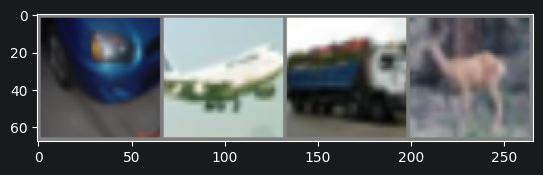

  car plane truck  deer


In [4]:
# Fonction pour afficher une image
def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.cpu().numpy()  # Ajouté .cpu() pour gérer GPU
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
print("Images affichées:")
imshow(torchvision.utils.make_grid(images))
print(' '.join('%5s' % classes[labels[j]] for j in range(min(4, len(labels)))))


# Model Creation



In [6]:
class AlexNet(nn.Module):
    def __init__(self, num_classes):
        super(AlexNet, self).__init__()  # ← AJOUTÉ (IMPORTANT!)
        self.features = nn.Sequential(
            # Feature extraction bloc 1
            nn.Conv2d(3, 64, kernel_size=11, stride=4, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            # Bloc 2
            nn.Conv2d(64, 192, kernel_size=5, stride=1, padding=2),  # ← CORRIGÉ stride
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            # Bloc 3
            nn.Conv2d(192, 384, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            # Bloc 4
            nn.Conv2d(384, 256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            # Bloc 5
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )
        self.avgpool = nn.AdaptiveAvgPool2d((6, 6))
        self.classifier = nn.Sequential(
            nn.Linear(6 * 6 * 256, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, num_classes),  # ← CORRIGÉ: output final
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), 256 * 6 * 6)
        logits = self.classifier(x)
        return logits

In [6]:
#from torchinfo import summary
#torchinfo.summary(AlexNet)

# DATA Pre-Processing

In [7]:
model = AlexNet(num_classes=10)

model = model.to(DEVICE)

optimizer = torch.optim.SGD(model.parameters(), momentum=0.9, lr=0.1)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.1, mode='max', verbose=True, )

minibatch_loss_list, train_acc_list, valid_acc_list = train_model(
    model=model,
    num_epochs=NUM_EPOCHES,
    train_loader=train_loader,
    valid_loader=valid_loader,
    test_loader=test_loader,
    optimizer=optimizer,
    device=DEVICE,
    scheduler=scheduler,
    scheduler_on='valid_acc',
    logging_interval=100)

plot_training_loss(minibatch_loss_list=minibatch_loss_list,
                   num_epochs=NUM_EPOCHES,
                   iter_per_epoch=len(train_loader),
                   results_dir=None,
                   averaging_iterations=200)
plt.show()

plot_accuracy(train_acc_list=train_acc_list,
              valid_acc_list=valid_acc_list,
              results_dir=None)
plt.ylim([60, 100])
plt.show()

TypeError: ReduceLROnPlateau.__init__() got an unexpected keyword argument 'verbose'

# Constrution of AlexNet Layer

# Training Model

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.optim import SGD
#import warnings
#from numpy import VisibleDeprecationWarning

#warnings.filterwarnings("ignore", category=VisibleDeprecationWarning)

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")


# MODÈLE CORRIGÉ
class AlexNet(nn.Module):
    def __init__(self, num_classes):
        super(AlexNet, self).__init__()  # ← AJOUTÉ (IMPORTANT!)
        self.features = nn.Sequential(
            # Feature extraction bloc 1
            nn.Conv2d(3, 64, kernel_size=11, stride=4, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            # Bloc 2
            nn.Conv2d(64, 192, kernel_size=5, stride=1, padding=2),  # ← CORRIGÉ stride
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            # Bloc 3
            nn.Conv2d(192, 384, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            # Bloc 4
            nn.Conv2d(384, 256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            # Bloc 5
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )
        self.avgpool = nn.AdaptiveAvgPool2d((6, 6))
        self.classifier = nn.Sequential(
            nn.Linear(6 * 6 * 256, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, num_classes),  # ← CORRIGÉ: output final
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), 256 * 6 * 6)
        logits = self.classifier(x)
        return logits


# BOUCLE D'ENTRAÎNEMENT COMPLÈTE
def train_epoch(model, train_loader, criterion, optimizer, device):
    """Entraîne le modèle pendant une époque."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Statistiques
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        if (batch_idx + 1) % 100 == 0:
            print(f'Batch [{batch_idx + 1}/{len(train_loader)}], '
                  f'Loss: {loss.item():.4f}')

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc


def validate(model, test_loader, criterion, device):
    """Évalue le modèle sur l'ensemble de validation/test."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = running_loss / len(test_loader)
    val_acc = 100 * correct / total
    return val_loss, val_acc


def train_model(model, num_epochs, train_loader, test_loader,
                optimizer, criterion, device, scheduler=None):
    """Fonction principale d'entraînement."""
    train_losses = []
    train_accs = []
    test_losses = []
    test_accs = []

    for epoch in range(num_epochs):
        # Entraînement
        train_loss, train_acc = train_epoch(model, train_loader,
                                            criterion, optimizer, device)
        train_losses.append(train_loss)
        train_accs.append(train_acc)

        # Validation
        test_loss, test_acc = validate(model, test_loader, criterion, device)
        test_losses.append(test_loss)
        test_accs.append(test_acc)

        # Scheduler (optionnel)
        if scheduler is not None:
            scheduler.step(test_acc)

        # Affichage
        print(f'Epoch [{epoch + 1}/{num_epochs}] '
              f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | '
              f'Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%')

    return train_losses, train_accs, test_losses, test_accs


# COURBES D'EFFICACITÉ
def plot_metrics(train_losses, train_accs, test_losses, test_accs):
    """Affiche les courbes de loss et accuracy."""
    epochs = range(1, len(train_losses) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss
    axes[0].plot(epochs, train_losses, 'b-', label='Train Loss')
    axes[0].plot(epochs, test_losses, 'r-', label='Test Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training and Test Loss')
    axes[0].legend()
    axes[0].grid(True)

    # Accuracy
    axes[1].plot(epochs, train_accs, 'b-', label='Train Accuracy')
    axes[1].plot(epochs, test_accs, 'r-', label='Test Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title('Training and Test Accuracy')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()


# ENTRAÎNEMENT COMPLET
if __name__ == "__main__":
    # Hyperparamètres
    NUM_EPOCHS = 50  # Réduit pour test rapide
    BATCH_SIZE = 256
    LEARNING_RATE = 0.001
    NUM_CLASSES = 10

    # Modèle
    model = AlexNet(num_classes=NUM_CLASSES).to(DEVICE)
    print(f"Modèle AlexNet créé et envoyé sur {DEVICE}")

    # Loss et Optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = SGD(model.parameters(), lr=LEARNING_RATE, momentum=0.9)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, factor=0.5, mode='max', patience=5
    )

    # Entraînement
    print("\n" + "=" * 60)
    print("DÉBUT DE L'ENTRAÎNEMENT")
    print("=" * 60 + "\n")

    train_losses, train_accs, test_losses, test_accs = train_model(
        model=model,
        num_epochs=NUM_EPOCHS,
        train_loader=trainloader,  # À partir de ton code précédent
        test_loader=testloader,  # À partir de ton code précédent
        optimizer=optimizer,
        criterion=criterion,
        device=DEVICE,
        scheduler=scheduler
    )

    print("\n" + "=" * 60)
    print("ENTRAÎNEMENT TERMINÉ")
    print("=" * 60)

    # Affichage des courbes
    plot_metrics(train_losses, train_accs, test_losses, test_accs)

    # Sauvegarde du modèle
    torch.save(model.state_dict(), './alexnet_cifar10.pth')
    print("Modèle sauvegardé dans './alexnet_cifar10.pth'")

Device: cpu
Modèle AlexNet créé et envoyé sur cpu

DÉBUT DE L'ENTRAÎNEMENT

Batch [100/12500], Loss: 2.3207
Batch [200/12500], Loss: 2.3010
Batch [300/12500], Loss: 2.2890
Batch [400/12500], Loss: 2.3129
Batch [500/12500], Loss: 2.3262
Batch [600/12500], Loss: 2.3395
Batch [700/12500], Loss: 2.2977
Batch [800/12500], Loss: 2.3248
Batch [900/12500], Loss: 2.3442
Batch [1000/12500], Loss: 2.3055
